<a href="https://colab.research.google.com/github/eniyah815-dotcom/machine-learning/blob/main/house_price_prediction_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("/content/1553768847-housing.csv")
data = data.drop("ocean_proximity", axis=1)

In [ ]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.6 MB


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=data.drop(['median_house_value'],axis=1)
y=data['median_house_value']

In [ ]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2)

In [ ]:
train_data=x_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
8060,-118.20,33.85,46,1854,462.0,1360,429,2.4844,158200
16449,-121.27,38.14,40,929,257.0,576,229,2.1250,137500
5518,-118.39,33.97,44,1097,186.0,513,185,6.2350,361400
9045,-118.13,34.68,28,718,124.0,347,121,4.0250,102600
9385,-122.47,37.89,23,10774,1736.0,3895,1683,7.2905,500001
...,...,...,...,...,...,...,...,...,...
5850,-118.32,34.18,49,192,41.0,83,38,3.0179,118800
11055,-117.85,33.77,16,2186,511.0,908,466,4.5750,225000
13388,-117.59,34.10,17,3646,1035.0,1987,895,2.3603,139300
15492,-117.21,33.13,19,3068,596.0,912,554,3.7750,168000


<Axes: >

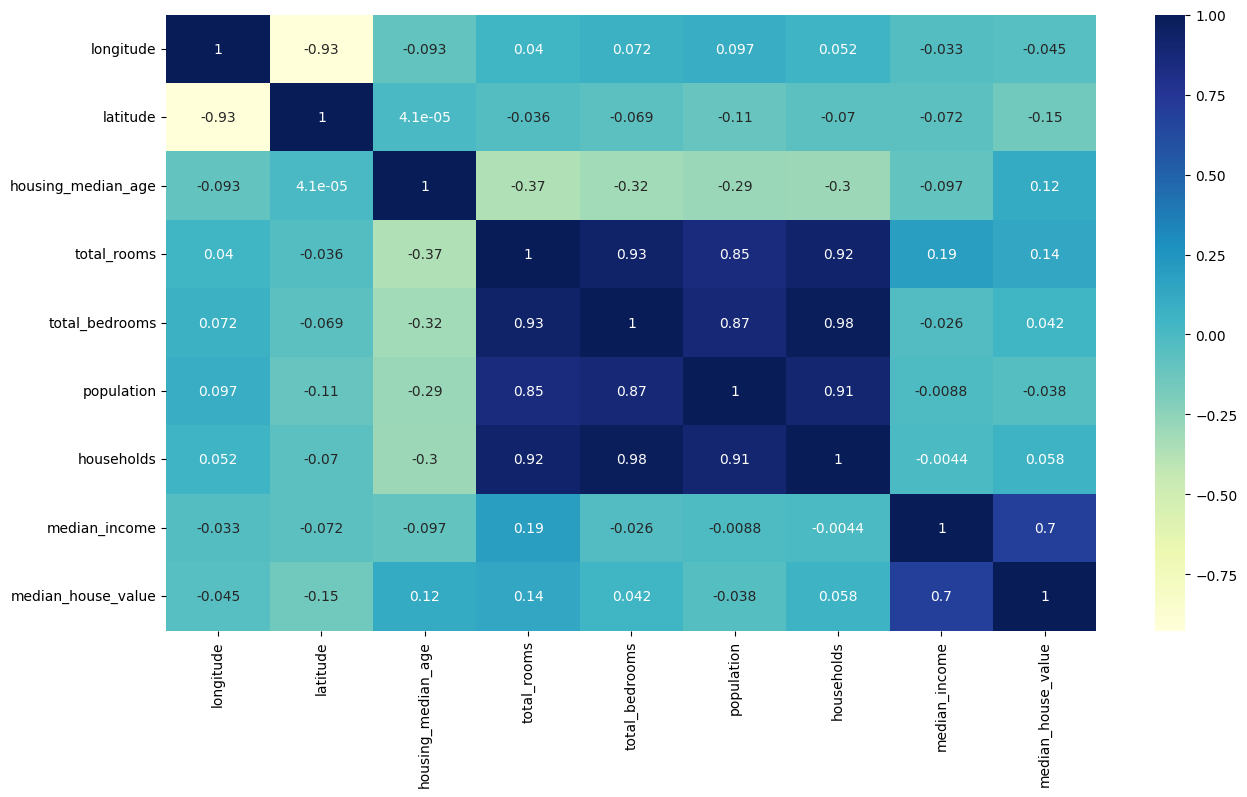

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(),annot=True,cmap="YlGnBu")

In [ ]:
x_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
8060,-118.20,33.85,46,1854,462.0,1360,429,2.4844
16449,-121.27,38.14,40,929,257.0,576,229,2.1250
5518,-118.39,33.97,44,1097,186.0,513,185,6.2350
9045,-118.13,34.68,28,718,124.0,347,121,4.0250
9385,-122.47,37.89,23,10774,1736.0,3895,1683,7.2905
...,...,...,...,...,...,...,...,...
5850,-118.32,34.18,49,192,41.0,83,38,3.0179
11055,-117.85,33.77,16,2186,511.0,908,466,4.5750
13388,-117.59,34.10,17,3646,1035.0,1987,895,2.3603
15492,-117.21,33.13,19,3068,596.0,912,554,3.7750


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

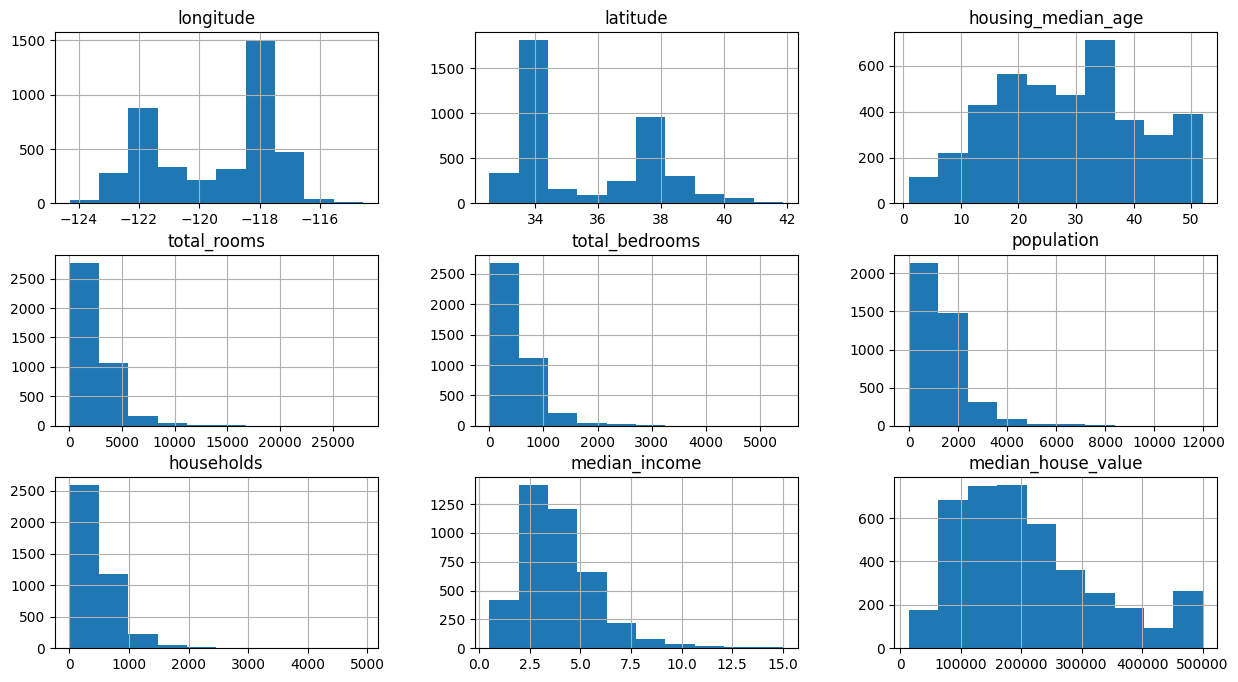

In [ ]:
train_data.hist(figsize=(15,8))

In [ ]:
train_data['total_bedrooms']=np.log(train_data['total_bedrooms']+1)
train_data['total_rooms']=np.log(train_data['total_rooms']+1)
train_data['population']=np.log(train_data['population']+1)
train_data['households']=np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

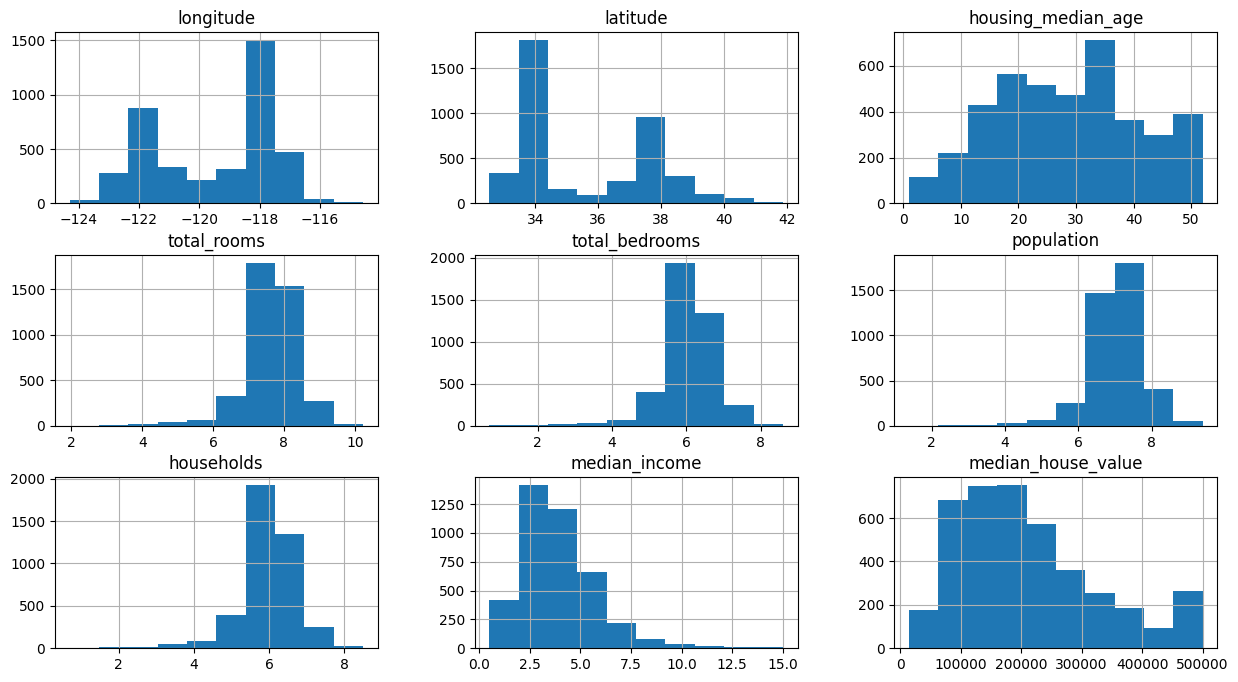

In [ ]:
train_data.hist(figsize=(15,8))

In [ ]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
8060,-118.20,33.85,46,7.525640,6.137727,7.215975,6.063785,2.4844,158200
16449,-121.27,38.14,40,6.835185,5.552960,6.357842,5.438079,2.1250,137500
5518,-118.39,33.97,44,7.001246,5.231109,6.242223,5.225747,6.2350,361400
9045,-118.13,34.68,28,6.577861,4.828314,5.852202,4.804021,4.0250,102600
9385,-122.47,37.89,23,9.284984,7.459915,8.267706,7.428927,7.2905,500001
...,...,...,...,...,...,...,...,...,...
5850,-118.32,34.18,49,5.262690,3.737670,4.430817,3.663562,3.0179,118800
11055,-117.85,33.77,16,7.690286,6.238325,6.812345,6.146329,4.5750,225000
13388,-117.59,34.10,17,8.201660,6.943122,7.594884,6.797940,2.3603,139300
15492,-117.21,33.13,19,8.029107,6.391917,6.816736,6.318968,3.7750,168000


<Axes: xlabel='longitude', ylabel='latitude'>

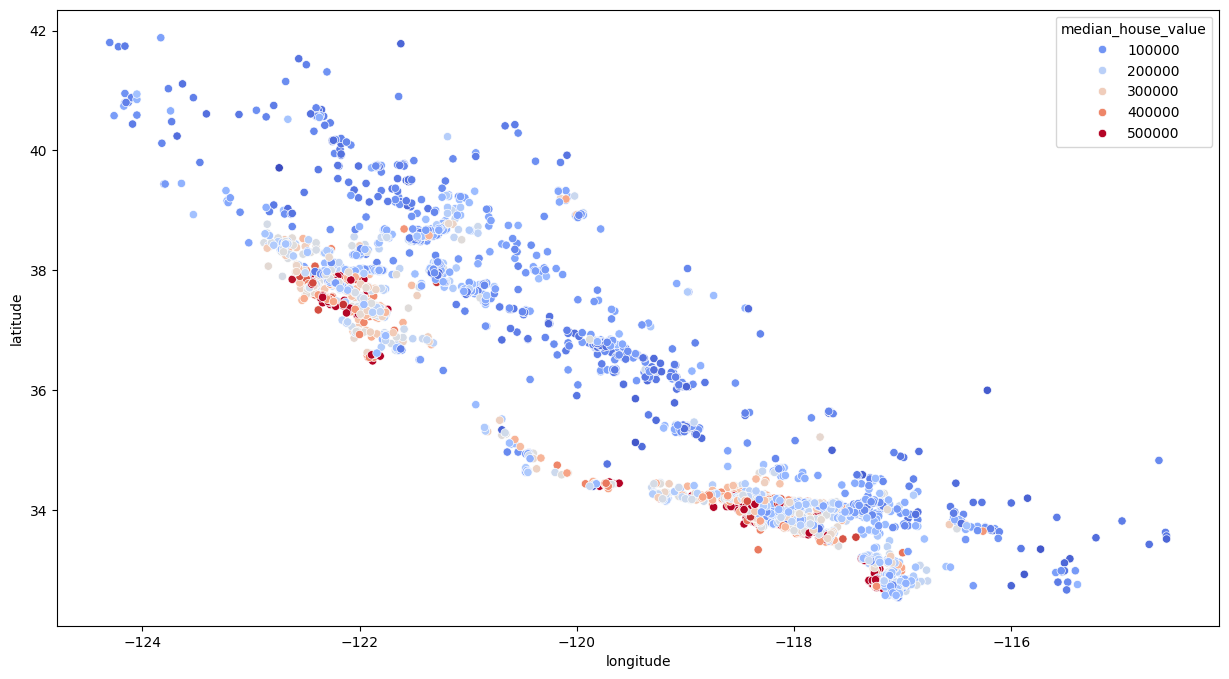

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='longitude',y='latitude',hue='median_house_value',data=train_data,palette='coolwarm')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train_s = scaler.fit_transform(x_train)

In [ ]:
reg=LinearRegression()
reg.fit(x_train_s,y_train)

LinearRegression()

In [ ]:
reg.score(x_train_s,y_train)

0.649163454401634

In [ ]:
x_test.iloc[[0]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
9341,-122.6,38.0,21,2198,462.0,1100,449,4.1098


In [53]:
reg.predict(scaler.transform(x_test.iloc[[0]]))

array([242308.58910662])

In [54]:
y_test.iloc[0]

np.int64(246600)